# Simulation summary statistics for downstream analysis

Choose a simulation for downstream variant forecasting tasks based on a selection of summary statistics that describe H3N2 HA flu populations in the literature 

## Package Imports

In [1]:
import os
import re
import json
import glob
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

# Seaborn's stripplot jitter comes from the global RNG with no seed of its
# own, so without this the figure shifts slightly on every render.
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from antigentools.supplement_style import (
    add_split_panel_letters,
    apply_supplement_style,
    seed_jitter,
    style_panel, hollow_boxes,
)

# Match S3-S6 rather than matplotlib's defaults.
apply_supplement_style()

## Helper functions

In [2]:
def summarize_stats(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Calculate mean and std dev for specified columns."""
    summary = pd.DataFrame({
        'statistic': columns,
        'mean': [df[col].mean() for col in columns],
        'std_dev': [df[col].std() for col in columns]
    })
    return summary

## Load sweep results

In [3]:
# Original flu-final build (kept for reproducibility when its files are present).
build_flu_final = 'flu-final'
# Round-1 review: the reviewer-runs sweep. S1/S2 summarize ALL simulations, so this
# is the batch name (not the single representative run).
build_review_1 = '2026-07-04-reviewer-runs'
build = build_review_1

# Freshly-aggregated batch sim_stats. find_candidate_runs.py writes it to the repo
# root; the data-tree copy under data/<build>/antigen-outputs/ is an older snapshot,
# so the review uses the root file.
stats_path_flu_final = f'../data/{build_flu_final}/antigen-outputs/sim_stats.csv'
stats_path_review_1 = '../sim_stats.csv'
stats_path = stats_path_review_1

In [4]:
stats_df = pd.read_csv(stats_path)
stats_df['run'] = stats_df['run'].astype(int)

# Fix non_epitope_acceptance and epitope_acceptance by parsing from path
# Path format: simulations/nonEpitopeAcceptance_X_epitopeAcceptance_Y/run_Z
stats_df['non_epitope_acceptance'] = stats_df['path'].str.extract(r'nonEpitopeAcceptance_(\d+\.?\d*)')[0].astype(float)
stats_df['epitope_acceptance'] = stats_df['path'].str.extract(r'epitopeAcceptance_(\d+\.?\d*)')[0].astype(float)

# Drop duplicates rows of path if any
stats_df = stats_df.drop_duplicates(subset=['path'])

print(f"Total runs: {stats_df.shape[0]}")

stats_df.head()

Total runs: 120


,path,run,I,N,R,S,antigenicDiversity,antigenic_movement_per_year,cases,diversity,...,tmrca,side_branch_epitope_mutations,side_branch_epitope_to_non-epitope_ratio,side_branch_non-epitope_mutations,trunk_epitope_mutations,trunk_epitope_to_non-epitope_ratio,trunk_non-epitope_mutations,branches_parse_failed,non_epitope_acceptance,epitope_acceptance
0,../antigen-experiments/experiments/2026-07-04-...,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,0.25,0.75
1,../antigen-experiments/experiments/2026-07-04-...,10,114095.2072,90000000.0,0.0,8.988590e+07,0.4299,1.328150,159808.3804,3.9318,...,3.6836,856.0,0.293553,2916.0,41.0,1.366667,30.0,False,0.25,0.75
2,../antigen-experiments/experiments/2026-07-04-...,14,143788.4182,90000000.0,0.0,8.985621e+07,0.4751,1.488398,201270.9316,3.4390,...,3.3435,959.0,0.316606,3029.0,50.0,1.923077,26.0,False,0.25,0.75
3,../antigen-experiments/experiments/2026-07-04-...,18,161635.5288,90000000.0,0.0,8.983836e+07,0.5375,1.856654,226527.3491,3.1410,...,2.8800,1007.0,0.318469,3162.0,71.0,0.922078,77.0,False,0.25,0.75
4,../antigen-experiments/experiments/2026-07-04-...,25,134467.8088,90000000.0,0.0,8.986553e+07,0.5395,1.603081,188345.2852,3.9412,...,3.7856,1029.0,0.333766,3083.0,45.0,4.090909,11.0,False,0.25,0.75


## Subset to valid runs

In [5]:
# Keep every run that produced statistics. The previous filter was
# `diversity <= 9.0`, which looked like outlier removal but was not: the maximum
# diversity across all 120 runs is 5.48, so the threshold never fired. What it
# actually dropped were rows whose metrics are all NaN, which fail the comparison.
# Those runs did not finish within their allocated resource time.
completed_stats_df = stats_df[~stats_df['branches_parse_failed']].copy()
n_total, n_done = len(stats_df), len(completed_stats_df)
print(f"Runs with statistics: {n_done} of {n_total} "
      f"({n_total - n_done} did not run to completion in the allocated time)")

# Flag the flu-like candidates so they can be drawn as filled points against
# hollow ones for the rest. sim_stats.csv paths are relative to this repo while
# candidate_runs.csv paths are absolute cluster paths, so join on the shared
# `simulations/<config>/run_<n>` suffix rather than the raw string.
candidates = pd.read_csv(
    f'../data/{build_review_1}/antigen-outputs/candidate_runs.csv'
)


def _run_key(path: str) -> str:
    match = re.search(r'simulations/([^/]+)/run_(\d+)$', path)
    assert match is not None, f'cannot parse a run key from {path!r}'
    return match.group(0)


candidate_keys = set(candidates['path'].map(_run_key))
completed_stats_df['is_flu_like'] = (
    completed_stats_df['path'].map(_run_key).isin(candidate_keys)
)
assert completed_stats_df['is_flu_like'].sum() == len(candidates), (
    'not every flu-like candidate matched a row in sim_stats.csv'
)
print(f"Flu-like candidates: {completed_stats_df['is_flu_like'].sum()} of {n_done}")
completed_stats_df.head()


Runs with statistics: 85 of 120 (35 did not run to completion in the allocated time)
Flu-like candidates: 45 of 85


,path,run,I,N,R,S,antigenicDiversity,antigenic_movement_per_year,cases,diversity,...,side_branch_epitope_mutations,side_branch_epitope_to_non-epitope_ratio,side_branch_non-epitope_mutations,trunk_epitope_mutations,trunk_epitope_to_non-epitope_ratio,trunk_non-epitope_mutations,branches_parse_failed,non_epitope_acceptance,epitope_acceptance,is_flu_like
1,../antigen-experiments/experiments/2026-07-04-...,10,114095.2072,90000000.0,0.0,8.988590e+07,0.4299,1.328150,159808.3804,3.9318,...,856.0,0.293553,2916.0,41.0,1.366667,30.0,False,0.25,0.75,True
2,../antigen-experiments/experiments/2026-07-04-...,14,143788.4182,90000000.0,0.0,8.985621e+07,0.4751,1.488398,201270.9316,3.4390,...,959.0,0.316606,3029.0,50.0,1.923077,26.0,False,0.25,0.75,True
3,../antigen-experiments/experiments/2026-07-04-...,18,161635.5288,90000000.0,0.0,8.983836e+07,0.5375,1.856654,226527.3491,3.1410,...,1007.0,0.318469,3162.0,71.0,0.922078,77.0,False,0.25,0.75,False
4,../antigen-experiments/experiments/2026-07-04-...,25,134467.8088,90000000.0,0.0,8.986553e+07,0.5395,1.603081,188345.2852,3.9412,...,1029.0,0.333766,3083.0,45.0,4.090909,11.0,False,0.25,0.75,True
5,../antigen-experiments/experiments/2026-07-04-...,24,153949.6598,90000000.0,0.0,8.984605e+07,0.6268,1.868891,215651.5230,3.5752,...,1046.0,0.332591,3145.0,60.0,0.952381,63.0,False,0.25,0.75,False


## Antigenic and genealogical summary stats

In [6]:
# Round-1 review figures go to reviews/round1/figures/; the original submission
# figures live in antigen-tex/figures/.
fig_dir_flu_final = '../../antigen-tex/figures'
fig_dir_review_1 = '../../antigen-tex/reviews/round1/figures'
fig_dir = fig_dir_review_1
base_stats_path = f'{fig_dir}/figureS1_base_antigen_summary_stats'

In [7]:
# Shared panel builder for S1 and S2. Both figures plot a metric against epitope
# acceptance rate, split by non-epitope acceptance rate, against a reference value
# from the literature -- so they differ only in which metrics and how many rows.

X_COL, HUE_COL = 'epitope_acceptance', 'non_epitope_acceptance'
X_ORDER = [0.75, 1.0]
HUE_ORDER = [0.2, 0.25]
# Okabe-Ito, the colourblind-safe pair figure S5 uses for FGA vs GARW.
ACCEPTANCE_COLORS = {0.2: '#D55E00', 0.25: '#0072B2'}
REFERENCE_COLOR = '#7f7f7f'          # matches the null/reference grey in S3 and S5

# A reference line this far outside the data range, as a fraction of that range,
# gets a broken axis rather than compressing every point into a corner.
BREAK_GAP_THRESHOLD = 0.3


def _reference_gap(values: pd.Series, reference: float) -> float:
    """How far outside the data a reference sits, in units of the data range."""
    low, high = values.min(), values.max()
    span = high - low
    if span <= 0:
        return 0.0
    if reference < low:
        return (low - reference) / span
    if reference > high:
        return (reference - high) / span
    return 0.0


def _draw_points(ax, data, column):
    """Box-and-whisker with a dodged strip overlay, flu-like runs filled.

    Follows figure S5's hued flavour of the idiom: faint dodged cloud underneath,
    hollow coloured boxes on top. Flu-like candidates are drawn filled and the
    remaining runs hollow, so the two are separable without spending a colour.
    """
    for flu_like, filled in ((True, True), (False, False)):
        subset = data[data['is_flu_like'] == flu_like]
        if subset.empty:
            continue
        first = len(ax.collections)
        seed_jitter()
        sns.stripplot(
            data=subset, x=X_COL, y=column, order=X_ORDER,
            hue=HUE_COL, hue_order=HUE_ORDER, palette=ACCEPTANCE_COLORS,
            dodge=True, jitter=0.18, size=5.5, linewidth=0.8,
            legend=False, ax=ax, zorder=1,
        )
        for coll in ax.collections[first:]:
            if not filled:
                # Hollow: keep the hue as the edge, knock the face out.
                coll.set_edgecolor(coll.get_facecolor())
                coll.set_facecolor('none')
            coll.set_rasterized(True)

    sns.boxplot(
        data=data, x=X_COL, y=column, order=X_ORDER,
        hue=HUE_COL, hue_order=HUE_ORDER, palette=ACCEPTANCE_COLORS,
        showfliers=False, linewidth=1.5, ax=ax, zorder=2,
    )
    # Transparent faces so the point cloud shows through, as in S5 panel A.
    hollow_boxes(ax)
    if ax.legend_ is not None:
        ax.legend_.remove()


def _add_break_marks(ax_top, ax_main):
    """Diagonal marks on the facing spines of a broken axis."""
    ax_top.spines['bottom'].set_visible(False)
    ax_main.spines['top'].set_visible(False)
    ax_top.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    d = 0.012
    for ax, ys in ((ax_top, (-d, +d)), (ax_main, (1 - d, 1 + d))):
        kw = dict(transform=ax.transAxes, color='k', clip_on=False, lw=1.0)
        ax.plot((-d, +d), ys, **kw)
        ax.plot((1 - d, 1 + d), ys, **kw)


def build_summary_figure(data, panels, n_rows, n_cols, figsize):
    """Draw one supplement summary figure.

    Args:
        data: Completed runs, carrying `is_flu_like`.
        panels: One dict per panel with `column`, `ylabel` and `reference`.
        n_rows, n_cols: Grid shape, filled in reading order.
        figsize: Canvas size in inches.

    Returns:
        The figure.
    """
    assert len(panels) == n_rows * n_cols, 'panel count must fill the grid'
    fig = plt.figure(figsize=figsize)
    grid = fig.add_gridspec(n_rows, n_cols)
    label_axes, top_axes = [], []

    for index, panel in enumerate(panels):
        row, col = divmod(index, n_cols)
        column, reference = panel['column'], panel['reference']
        broken = (
            reference is not None
            and _reference_gap(data[column], reference) > BREAK_GAP_THRESHOLD
        )

        if broken:
            # A short upper axes carries the off-scale reference; the data keeps
            # its own scale below.
            inner = grid[row, col].subgridspec(2, 1, height_ratios=[1, 4], hspace=0.06)
            ax_top = fig.add_subplot(inner[0])
            ax_main = fig.add_subplot(inner[1], sharex=ax_top)
        else:
            ax_main = fig.add_subplot(grid[row, col])
            ax_top = ax_main

        _draw_points(ax_main, data, column)

        if reference is not None:
            target = ax_top if broken else ax_main
            target.axhline(reference, ls='--', lw=1.5, color=REFERENCE_COLOR, zorder=3)

        if broken:
            low, high = data[column].min(), data[column].max()
            pad = 0.08 * (high - low)
            ax_main.set_ylim(low - pad, high + pad)
            ax_top.set_ylim(reference - pad, reference + pad)
            ax_top.set_yticks([reference])
            style_panel(ax_top)
            _add_break_marks(ax_top, ax_main)

        style_panel(ax_main)
        ax_main.set_ylabel(panel['ylabel'])
        # One shared x-label under the bottom row only, as in S4.
        ax_main.set_xlabel('Epitope acceptance rate' if row == n_rows - 1 else '')
        label_axes.append(ax_main)
        top_axes.append(ax_top)

    # No legend title: it would sit over all five entries while describing only
    # the first two, so the acceptance rate is spelled out in those labels instead.
    handles = [
        Patch(facecolor='none', edgecolor=ACCEPTANCE_COLORS[v], linewidth=2,
              label=f'Non-epitope acc. rate = {v}')
        for v in HUE_ORDER
    ] + [
        Line2D([], [], marker='o', ls='none', markeredgecolor='0.35',
               markerfacecolor='0.35', ms=7, label='flu-like candidate'),
        Line2D([], [], marker='o', ls='none', markeredgecolor='0.35',
               markerfacecolor='none', markeredgewidth=1.2, ms=7, label='discarded run'),
        Line2D([], [], color=REFERENCE_COLOR, ls='--', lw=1.5,
               label='empirical / target value'),
    ]
    fig.legend(handles=handles, ncol=5, loc='lower center',
               bbox_to_anchor=(0.5, -0.06), frameon=False)

    fig.tight_layout(rect=(0, 0.04, 1, 1), h_pad=3.0)
    add_split_panel_letters(fig, label_axes, top_axes,
                            'ABCDEFGHI'[:len(panels)])
    return fig


Wrote ../../antigen-tex/reviews/round1/figures/figureS1_base_antigen_summary_stats.pdf


Wrote ../../antigen-tex/reviews/round1/figures/figureS1_base_antigen_summary_stats.png


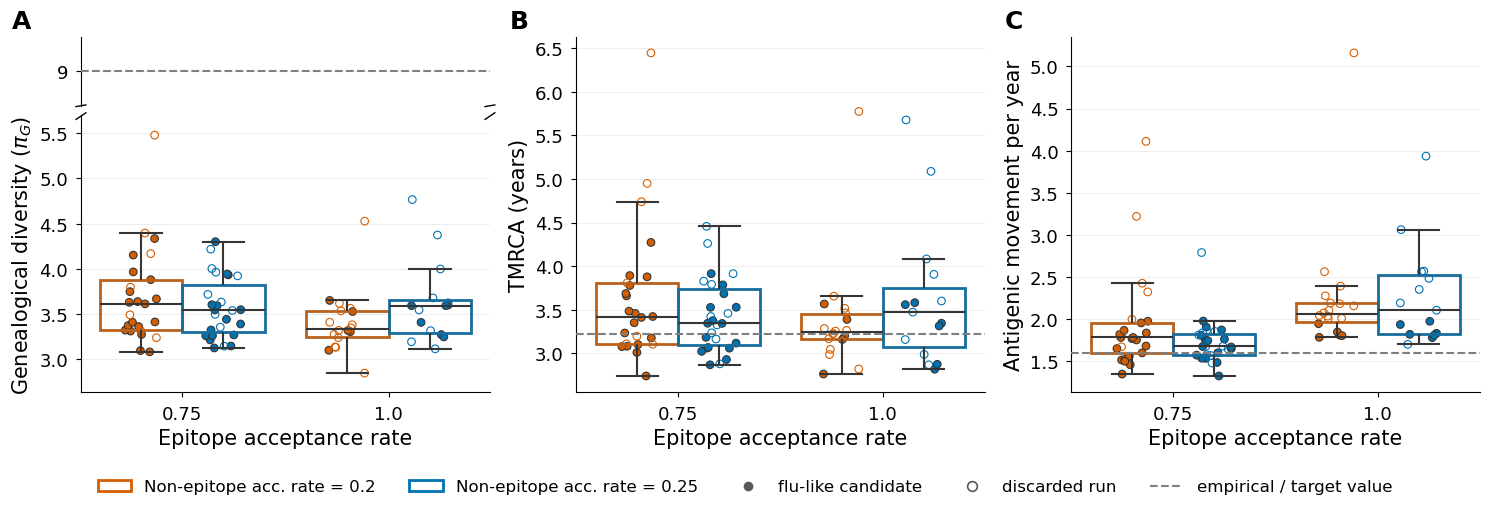

In [8]:
panels_s1 = [
    {'column': 'diversity',
     'ylabel': r'Genealogical diversity ($\pi_G$)',
     'reference': 9.0},
    {'column': 'tmrca',
     'ylabel': 'TMRCA (years)',
     'reference': 3.22},
    {'column': 'antigenic_movement_per_year',
     'ylabel': 'Antigenic movement per year',
     'reference': 1.6},
]

fig = build_summary_figure(completed_stats_df, panels_s1,
                           n_rows=1, n_cols=3, figsize=(15.0, 4.6))
for ext in ('pdf', 'png'):
    fig.savefig(f'{base_stats_path}.{ext}', dpi=300, bbox_inches='tight')
    print(f'Wrote {base_stats_path}.{ext}')
plt.show()


In [9]:
# Example usage
summarize_stats(completed_stats_df, ['diversity', 'tmrca', 'antigenic_movement_per_year'])

,statistic,mean,std_dev
0,diversity,3.576039,0.427208
1,tmrca,3.514531,0.661097
2,antigenic_movement_per_year,1.992081,0.590891


## Sequence mutation summary stats

In [10]:
new_stats_path = f'{fig_dir}/figureS2_new_antigen_summary_stats'

Wrote ../../antigen-tex/reviews/round1/figures/figureS2_new_antigen_summary_stats.pdf


Wrote ../../antigen-tex/reviews/round1/figures/figureS2_new_antigen_summary_stats.png


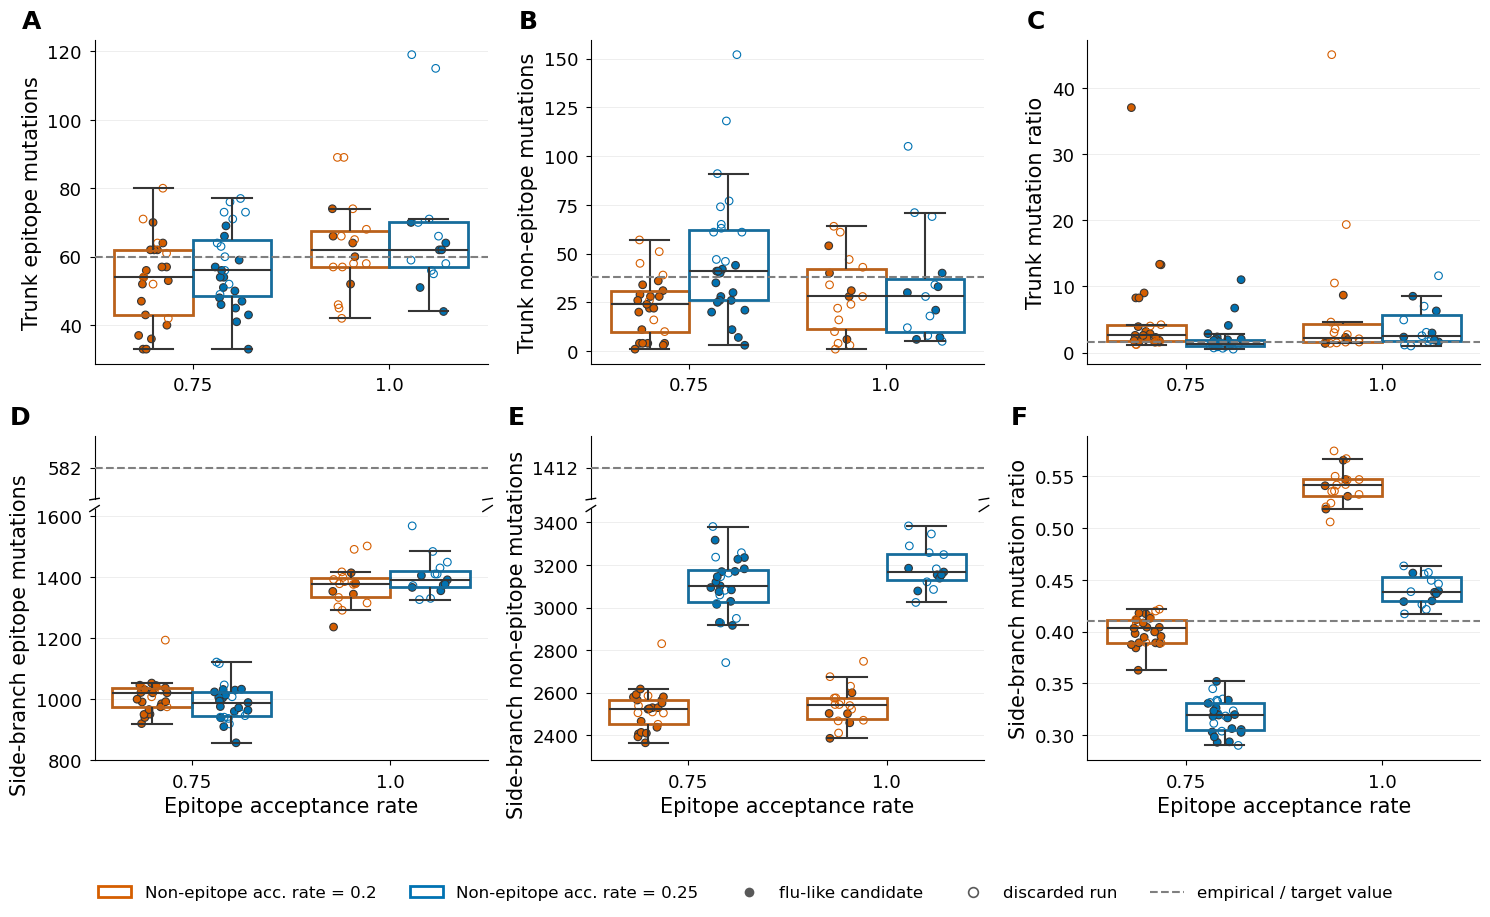

In [11]:
panels_s2 = [
    {'column': 'trunk_epitope_mutations',
     'ylabel': 'Trunk epitope mutations', 'reference': 60},
    {'column': 'trunk_non-epitope_mutations',
     'ylabel': 'Trunk non-epitope mutations', 'reference': 38},
    {'column': 'trunk_epitope_to_non-epitope_ratio',
     'ylabel': 'Trunk mutation ratio', 'reference': 1.56},
    {'column': 'side_branch_epitope_mutations',
     'ylabel': 'Side-branch epitope mutations', 'reference': 582},
    {'column': 'side_branch_non-epitope_mutations',
     'ylabel': 'Side-branch non-epitope mutations', 'reference': 1412},
    {'column': 'side_branch_epitope_to_non-epitope_ratio',
     'ylabel': 'Side-branch mutation ratio', 'reference': 0.41},
]

fig = build_summary_figure(completed_stats_df, panels_s2,
                           n_rows=2, n_cols=3, figsize=(15.0, 8.4))
for ext in ('pdf', 'png'):
    fig.savefig(f'{new_stats_path}.{ext}', dpi=300, bbox_inches='tight')
    print(f'Wrote {new_stats_path}.{ext}')
plt.show()


In [12]:
summarize_stats(completed_stats_df, [p['column'] for p in panels_s2])


,statistic,mean,std_dev
0,trunk_epitope_mutations,59.141176,14.930915
1,trunk_non-epitope_mutations,33.800000,27.210292
2,trunk_epitope_to_non-epitope_ratio,4.240797,6.718613
3,side_branch_epitope_mutations,1148.235294,199.539270
4,side_branch_non-epitope_mutations,2826.376471,324.945306
5,side_branch_epitope_to_non-epitope_ratio,0.411000,0.082255
